
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2026**

---

# Trabajo práctico entregable - Parte 2

# Grupo 22

In [ ]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn as sns

#seaborn.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [ ]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

In [ ]:
df[:3]

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0


In [ ]:
df.profile_gender.unique()

array(['Mujer Cis', 'Hombre Cis', 'Prefiero no decir', 'Trans', 'Queer',
       'No binarie', 'Agénero', nan], dtype=object)

In [ ]:
df.loc[:,'profile_g'] = df.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

In [ ]:
alpha = 0.05

In [ ]:
is_man = df.profile_g == 'Varón cis'
is_woman = df.profile_g == 'Mujer cis'


Para garantizar comparabilidad entre los grupos, se utiliza el mismo criterio de filtrado salarial en ambos casos. Ya que se consideró que los filtros no eran simétricos, por lo que se corrige esa definición antes de realizar la estimación de la diferencia de medias.

In [ ]:
groupA = df[(15000000>df.salary_monthly_NETO)&(df.salary_monthly_NETO > 100000) & is_man].salary_monthly_NETO
groupB  = df[(15000000>df.salary_monthly_NETO)&(df.salary_monthly_NETO > 100000) & is_woman].salary_monthly_NETO

In [ ]:
print(f"Grupo A (Varones cis): n_A = {len(groupA)}")
print(f"Grupo B (Mujeres cis): n_B = {len(groupB)}")

Grupo A (Varones cis): n_A = 3657
Grupo B (Mujeres cis): n_B = 933


In [ ]:
print(f"Mean: {groupA.mean()}")
print(f"Median: {groupA.median()}")
print(f"Standard Deviation: {groupA.std()}")

Mean: 3341727.1084495485
Median: 2900000.0
Standard Deviation: 2063001.8896339927


In [ ]:
print(f"Mean: {groupB.mean()}")
print(f"Median: {groupB.median()}")
print(f"Standard Deviation: {groupB.std()}")

Mean: 2670496.9029474813
Median: 2329058.0
Standard Deviation: 1526309.4699291997


Text(0.5, 0, 'Salary')

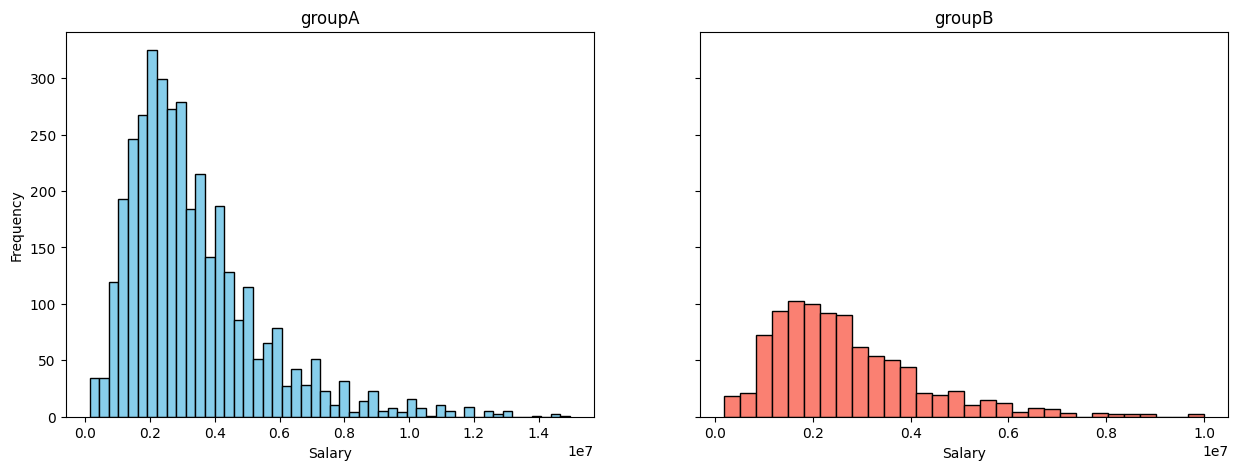

In [ ]:


# Create the histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)  # 1 row, 3 columns

# Plot each group on a separate subplot
axes[0].hist(groupA, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('groupA')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

axes[1].hist(groupB, bins=30, color='salmon', edgecolor='black')
axes[1].set_title('groupB')
axes[1].set_xlabel('Salary')




## Ejercicio 1: Estimación

**Consigna:**  Calcular una estimación puntual y un intervalo de confianza de nivel (1-alpha) para la resta entre la media del salario Neto para Hombres y la media del salario Neto para mujeres (diferencia de las medias entre el grupoA y grupoB).
¿Cómo se relaciona este intervalo de confianza con el test de hipótesis para diferencia de medias?

**Razonamiento**: Vamos a importar las bibliotecas necesarias: `numpy, scipy.stats` y `statsmodels.stats.weightstats`, tal como se ve en las instrucciones para calcular el intervalo de confianza. Y luego pasamos a calcular la media, la desviación estándar y el tamaño de la muestra para ambos grupos, luego la estimación puntual de la diferencia, el error estándar de la diferencia, los grados de libertad de Welch y, al final, armaremos el intervalo de confianza del 95% para la diferencia de medias, como se indicó.



In [ ]:
import numpy as np
from scipy import stats
import statsmodels.stats.weightstats as sm_stats
import pandas as pd

# Redefinir df y alpha, y los grupos para garantizar que estén disponibles.
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2026_processed.csv'
df = pd.read_csv(url)

df.loc[:,'profile_g'] = df.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

alpha = 0.05
is_man = df.profile_g == 'Varón cis'
is_woman = df.profile_g == 'Mujer cis'

groupA = df[(15000000>df.salary_monthly_NETO)&(df.salary_monthly_NETO > 100000) & is_man].salary_monthly_NETO
groupB  = df[(15000000>df.salary_monthly_NETO)&(df.salary_monthly_NETO > 100000) & is_woman].salary_monthly_NETO

# 1. Calcular las medias y desviaciones estándar para referencia
mean_A = groupA.mean()
mean_B = groupB.mean()
std_A = groupA.std()
std_B = groupB.std()
n_A = len(groupA)
n_B = len(groupB)

# 2. Realizar la estimación puntual de la diferencia de medias
point_estimate_diff = mean_A - mean_B
print(f"Estimación puntual de la diferencia de medias (groupA - groupB): {point_estimate_diff:,.2f}\n")

# 3. Calcular del Error Estándar de la diferencia para Welch's t-test
se_diff = np.sqrt((std_A**2 / n_A) + (std_B**2 / n_B))

# 4. Obtener los grados de libertad para Welch's t-test (ecuacion de Welch-Satterthwaite)
# Llamar a ttest_ind para obtener t_stat y p_value, pero df se calcula por separado si no se devuelve.
# En algunas versiones de scipy, ttest_ind devuelve df, pero si no lo hace, lo calculamos manualmente.

# Realizar la prueba t de Welch para obtener el estadístico t y el valor p.
t_stat, p_value = stats.ttest_ind(groupA, groupB, equal_var=False, alternative='two-sided')

# Calcular manualmente los grados de libertad para la prueba t de Welch.
num = (std_A**2 / n_A + std_B**2 / n_B)**2
denom = (std_A**2 / n_A)**2 / (n_A - 1) + (std_B**2 / n_B)**2 / (n_B - 1)
df_welch = num / denom

# 5. Construir el intervalo de confianza (1-alpha)
confidence_level = 1 - alpha # alpha ya está definido como 0.05
lower_bound, upper_bound = stats.t.interval(confidence=confidence_level,
                                            df=df_welch,
                                            loc=point_estimate_diff,
                                            scale=se_diff)

print(f"Intervalo de Confianza del {confidence_level*100:.0f}% para la diferencia de medias:")
print(f"[{lower_bound:,.2f}, {upper_bound:,.2f}]")

# Interpretación
print("\n--- Interpretación del Intervalo de Confianza ---")
print(f"La estimación puntual de la diferencia entre el salario neto promedio de hombres (groupA) y mujeres (groupB) es de ${point_estimate_diff:,.2f}.")
print(f"El intervalo de confianza del {confidence_level*100:.0f}% para esta diferencia es de [{lower_bound:,.2f}, {upper_bound:,.2f}].")
print("Esto significa que, si repitiéramos este estudio muchas veces y calcularamos un intervalo de confianza cada vez,")
print(f"esperaríamos que el {confidence_level*100:.0f}% de esos intervalos contuviera la verdadera diferencia poblacional entre los salarios medios de ambos grupos.")

print("\n--- Relación con el Test de Hipótesis ---")
print("Este intervalo de confianza se relaciona directamente con un test de hipótesis para la diferencia de medias.")
print("Si el intervalo de confianza NO incluye el valor cero, podemos rechazar la hipótesis nula (H0) de que no hay diferencia")
print("entre las medias salariales de groupA y groupB, a un nivel de significancia de alpha.")
print("En nuestro caso:")
if lower_bound <= 0 <= upper_bound:
    print(f"Dado que el intervalo [{lower_bound:,.2f}, {upper_bound:,.2f}] Si contiene el cero,")
    print(f"NO rechazariamos la hipotesis nula de que no hay diferencia significativa entre los salarios netos promedio de hombres y mujeres, al nivel de significancia de {alpha}.")
else:
    print(f"Dado que el intervalo [{lower_bound:,.2f}, {upper_bound:,.2f}] NO contiene el cero,")
    print(f"RECHAZARIAMOS la hipotesis nula de que no hay diferencia significativa entre los salarios netos promedio de hombres y mujeres, al nivel de significancia de {alpha}.")

Estimación puntual de la diferencia de medias (groupA - groupB): 671,230.21

Intervalo de Confianza del 95% para la diferencia de medias:
[552,569.38, 789,891.03]

--- Interpretación del Intervalo de Confianza ---
La estimación puntual de la diferencia entre el salario neto promedio de hombres (groupA) y mujeres (groupB) es de $671,230.21.
El intervalo de confianza del 95% para esta diferencia es de [552,569.38, 789,891.03].
Esto significa que, si repitiéramos este estudio muchas veces y calcularamos un intervalo de confianza cada vez,
esperaríamos que el 95% de esos intervalos contuviera la verdadera diferencia poblacional entre los salarios medios de ambos grupos.

--- Relación con el Test de Hipótesis ---
Este intervalo de confianza se relaciona directamente con un test de hipótesis para la diferencia de medias.
Si el intervalo de confianza NO incluye el valor cero, podemos rechazar la hipótesis nula (H0) de que no hay diferencia
entre las medias salariales de groupA y groupB, a un 

## Ejercicio 2: Test de hipótesis



### 2.1 Formalización

Describir formalmente los distintos componentes de un test de hipótesis para comprobar si la distribución de los salarios es distinta entre los grupos A y B.

**Hipótesis Nula**

$H_0=...$

**Estadístico (Pivote)**
  * Identificar el estadístico
  * Escribir qué distribución tiene bajo $H_0$


Para comprobar si la distribución de los salarios netos es distinta entre el grupo de hombres (groupA) y el grupo de mujeres (groupB), formalizamos el test de hipótesis de la siguiente manera:

**Hipótesis Nula ($H_0$)**:
No hay diferencia en la media de los salarios netos entre el grupo de hombres y el grupo de mujeres. Matemáticamente, esto se expresa como:

$H_0: \mu_A = \mu_B$

Donde $\mu_A$ es la media poblacional del salario neto para `groupA` (hombres) y $\mu_B$ es la media poblacional del salario neto para `groupB` (mujeres).

**Hipótesis Alternativa ($H_1$)**:
Existe una diferencia en la media de los salarios netos entre el grupo de hombres y el grupo de mujeres. Matemáticamente, esto se expresa como:

$H_1: \mu_A \neq \mu_B$

Esta es una prueba de dos colas, ya que estamos interesados en detectar cualquier diferencia, ya sea que la media de `groupA` sea mayor o menor que la de `groupB`.

**Estadístico de Prueba (Pivote)**:
Dado que las varianzas de los dos grupos no se asumen iguales (como se infiere del uso de Welch's t-test en el ejercicio 1), el estadístico de prueba adecuado es el t-estadístico de Welch. Se calcula como:

$t = \frac{(\bar{x}_A - \bar{x}_B) - (\mu_A - \mu_B)}{\sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}}$

Bajo la hipótesis nula ($H_0: \mu_A = \mu_B$), la fórmula se simplifica a:

$t = \frac{\bar{x}_A - \bar{x}_B}{\sqrt{\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B}}}$

Donde:
* $\bar{x}_A$ y $\bar{x}_B$ son las medias muestrales de los salarios netos para `groupA` y `groupB`, respectivamente.
* $s_A^2$ y $s_B^2$ son las varianzas muestrales de los salarios netos para `groupA` y `groupB`, respectivamente.
* $n_A$ y $n_B$ son los tamaños de las muestras para `groupA` y `groupB`, respectivamente.

**Distribución del Estadístico Bajo $H_0$**:
Bajo la hipótesis nula, el t-estadístico de Welch sigue aproximadamente una distribución t de Student. Los grados de libertad (df) para esta distribución se calculan utilizando la ecuación de Welch-Satterthwaite:

$df = \frac{(\frac{s_A^2}{n_A} + \frac{s_B^2}{n_B})^2}{\frac{(s_A^2 / n_A)^2}{n_A - 1} + \frac{(s_B^2 / n_B)^2}{n_B - 1}}$

Esta distribución nos permite calcular el p-valor, que es la probabilidad de observar un estadístico de prueba tan extremo o más extremo que el calculado, asumiendo que la hipótesis nula es verdadera. Si el p-valor es menor que el nivel de significancia $\alpha$ (en este caso, 0.05), rechazamos la hipótesis nula.

### 2.2 P-valor

1. Calcule el p-valor y decida si rechazar o no la hipótesis nula.
2. Interprete el resultado.

Links útiles:
* [Test de hipótesis usando scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
* [Test de Welch](http://daniellakens.blogspot.com/2015/01/always-use-welchs-t-test-instead-of.html)


**Razonamineto**: Vamos a calcular el p-valor utilizando el test de Welch para comparar los salarios de groupA y groupB. Interpretar el resultado comparándolo con el nivel de significancia (alpha) y decidir si se rechaza o no la hipótesis nula en el contexto de los salarios.

Esto requerira calcular el valor p mediante la prueba t de Welch, compararlo con alfa e interpretar los resultados. Esto implica usar `scipy.stats.ttest_ind` y lógica condicional para la interpretación, que se puede realizar en un único bloque de código.



In [ ]:
from scipy import stats

# 1. Realizar el test de Welch para obtener el estadístico t y el p-valor
t_statistic, p_value = stats.ttest_ind(groupA, groupB, equal_var=False, alternative='two-sided')
# 2. Almacenar el p-valor resultante en una variable (hecho arriba)

# 3. Mostrar el estadistico t y el p valor calculado
print(f"P-valor (Welch's t-test): {p_value:.30f}")
print(f"Estadistico t: {t_statistic:.4f}")

# 4. Comparar el p-valor con el nivel de significancia alpha
# alpha ya está definido como 0.05
print(f"Nivel de significancia (alpha): {alpha}")

# 5. Decidir si se rechaza o no la hipótesis nula
print("\n--- Decisión sobre la Hipótesis Nula ---")
if p_value < alpha:
    print("Dado que el p-valor es mucho menor que alpha, RECHAZAMOS la hipótesis nula.")
    print("Esto sugiere que hay una diferencia estadísticamente significativa en los salarios netos promedio entre groupA y groupB.")
else:
    print("Dado que el p-valor es mayor o igual que alpha, NO RECHAZAMOS la hipótesis nula.")
    print("Esto sugiere que no hay suficiente evidencia para afirmar que existe una diferencia estadísticamente significativa en los salarios netos promedio entre groupA y groupB.")

# 6. Interpretar el resultado en el contexto de la diferencia salarial
print("\n--- Interpretación del Resultado ---")
if p_value < alpha:
    print(f"Con un p-valor tan bajo, tenemos evidencia estadística para concluir que")
    print("el salario neto promedio de los hombres (groupA) es significativamente diferente al de las mujeres (groupB).")
    print(f"Específicamente, dado que la media de groupA ({groupA.mean():,.2f}) es mayor que la de groupB ({groupB.mean():,.2f}),")
    print("podemos inferir que, en promedio, los hombres tienen salarios netos más altos que las mujeres en esta muestra.")
else:
    print(f"Con un p-valor de {p_value:.4f} (mayor o igual que {alpha}), no tenemos evidencia estadística suficiente para concluir que")
    print("existe una diferencia significativa en los salarios netos promedio entre hombres (groupA) y mujeres (groupB).")

P-valor (Welch's t-test): 0.000000000000000000000000000937
Estadistico t: 11.0940
Nivel de significancia (alpha): 0.05

--- Decisión sobre la Hipótesis Nula ---
Dado que el p-valor es mucho menor que alpha, RECHAZAMOS la hipótesis nula.
Esto sugiere que hay una diferencia estadísticamente significativa en los salarios netos promedio entre groupA y groupB.

--- Interpretación del Resultado ---
Con un p-valor tan bajo, tenemos evidencia estadística para concluir que
el salario neto promedio de los hombres (groupA) es significativamente diferente al de las mujeres (groupB).
Específicamente, dado que la media de groupA (3,341,727.11) es mayor que la de groupB (2,670,496.90),
podemos inferir que, en promedio, los hombres tienen salarios netos más altos que las mujeres en esta muestra.


### [Opcional] 2.3 Potencia del test

Nuestra muestra, ¿era lo suficientemente grande para detectar si existe o no una diferencia entre los grupos?

1. Utilice la función `tt_ind_solve_power` para calcular el tamaño necesario de la muestra para un poder estadístico de 0.8, 0.9 y 0.95, asumiendo una significancia estadística de 0.05.
2. ¿Cómo intepretan el poder estadístico de un test? Dado su conocimiento de dominio sobre los datos, ¿les parece que esta muestra es lo suficientemente grande para ser representativo de la tendencia general? ¿y para utilizarlo en un juicio penal contra una empresa XX por una causa de discriminación?

[Documentación](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.tt_ind_solve_power.html)

NOTA: este análisis debería hacerse ANTES de recolectar los datos.

In [ ]:
from statsmodels.stats.power import tt_ind_solve_power

In [ ]:
effect_size = (groupA.mean() - groupB.mean()) / groupB.std()
# nobs1=None  - What we want to know
alpha = 0.05
ratio = len(groupB) / len(groupA)
power= 0.8

In [ ]:
print(effect_size)

0.43977333478328173


In [ ]:
tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=power,  ratio=ratio)

201.1966453541089

In [ ]:
from statsmodels.stats.power import tt_ind_solve_power

effect_size = (groupA.mean() - groupB.mean()) / groupB.std()
alpha = 0.05
ratio = len(groupB) / len(groupA)

for power in [0.8, 0.9, 0.95]:
    n_necesario = tt_ind_solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        ratio=ratio
    )
    print(f"Potencia {power*100:.0f}%: se necesitan {n_necesario:.0f} obs. en grupo A")

Potencia 80%: se necesitan 201 obs. en grupo A
Potencia 90%: se necesitan 269 obs. en grupo A
Potencia 95%: se necesitan 332 obs. en grupo A


El poder estadístico de un test es la probabilidad de rechazar H₀ cuando
efectivamente es falsa. Una potencia de 0.8 por ejemplo implica que si existe
una diferencia real entre los grupos, el test la detectará en el
80% de los casos.

Para el análisis general de tendencias: dado que nuestras muestras
tienen 3657 y 933 observaciones, y el n necesario para potencia
0.8 según el cálculo realizado previamente es de 201 para el grupo A, por lo tanto la muestra es suficientemente grande. Existe un riesgo despreciable de cometer un error de tipo II (diferencia real entre los grupos que el test no detecta).

Para un juicio penal entendemos que la exigencia que se la hace el test debería ser mayor. Una potencia de 0.95 o más sería lo aceptable y por ende un n superior al que se dispone en este caso. Sería ideal no limitarse a utilizar estos resultados por sí solos como prueba concluyente en un juicio por discriminación laboral.

Se necesitaría información adicional, así como, controlar otras variables relevantes como experiencia, seniority, tipo de puesto, carga horaria, etc.

## Ejercicio 3: Comunicación y visualización

**Consigna:** Seleccionen un resultado que les parezca relevante a partir de alguno de los ejercicios del entregable. Diseñe e implemente una comunicación en base a este mensaje, en un archivo PDF.

Elija las palabras y visualización más adecuada para que la comunicación sea entendible, efectiva y se dapte a UNA de las siguientes situaciones:

1. Una sección en un artículo de difusión a presentar como parte de una organización sin fines de lucro.
No más de 1 página A4 (o dos si los gráficos son muy grandes).
  1. Ejemplo: Alguna de las secciones [Los ecosistemas de emprendimiento de América Latina y el Caribe frente al COVID-19: Impactos, necesidades y recomendaciones](https://publications.iadb.org/es/los-ecosistemas-de-emprendimiento-de-america-latina-y-el-caribe-frente-al-covid-19-impactos-necesidades-y-recomendaciones), por ejemplo la sección *2.2. Reacciones de los emprendedores*.
  2. Ejemplo: Alguna de las secciones de [The state of gender pay gap in 2021](https://www.payscale.com/data/gender-pay-gap?tk=carousel-ps-rc-job)
  3. Puntos clave:
    1. Simpleza de los gráficos.
    2. Comunicación en lenguaje simple a personas que no son necesariamente expertos de dominio.
    2. Selección de UNA oración sobre la que se hace énfasis.
    3. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

2. Una publicación científica o reporte técnico interno. No más de una página A4:
  2. Ejemplo: La sección de resultados de [IZA DP No. 12914: The Impact of a Minimum Wage Change on the Distribution of Wages and Household Income](https://www.iza.org/publications/dp/12914/the-impact-of-a-minimum-wage-change-on-the-distribution-of-wages-and-household-income).
  2. Ejemplo: Alguna de las secciones de [Temporary reduction in daily global CO2 emissions during the COVID-19 forced confinement](https://www.nature.com/articles/s41558-020-0797-x)
  3. Puntos clave:
    3. Nivel de detalle técnico requerido. Es necesario justificar la validez del análisis.
    4. La idea presentada puede ser más compleja. Pueden asumir que la audiencia tiene conocimiento técnico y va a analizar las visualizaciones en detalle.
    5. Pueden presentar más en detalle las limitaciones del análisis (significancia estadística, etc.)
    2. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

3. Un tweet (o post de LinkedIn) para la cuenta de su empresa consultora que hace análisis de datos. El objetivo es promocionar un análisis de datos abiertos que van a incluir en su portfolio:
  1. Ejemplo: [Comparación vacunas covid](https://twitter.com/infobeautiful/status/1381577746527236098?s=20)
  2. Ejemplo: [Tweet del BID](https://twitter.com/el_BID/status/1388508583944507396?s=20). Lo valioso de este tweet es que usaron un único número para transmitir un mensaje. Puede ser algo así, o con un gráfico muy simple.
  3. Ejemplo: [Cambio climático](https://twitter.com/UNFCCC/status/1387732156190011394?s=20) Es un muy buen ejemplo, excepto que el gráfico no se lee nada y hay que entrar a la publicación original.
  3. Ejemplo: [¿Cuánto están los programadores en las empresas?](https://www.linkedin.com/posts/denis-rothman-0b034043_tech-career-work-activity-6793861923269054464-gS6y) (No verificamos la veracidad o seriedad de la fuente).
  4. Puntos clave:
    1. Su audiencia no va a mirar la visualización por más de unos segundos, y no tiene conocimiento técnico.
  3. Tienen que incluir además una *breve* descripción de cómo obtuvieron los datos que están presentando, que no entraría en el tweet.


### Comunicación y visualización - Post de LinkedIn/Tweet

Vamos a crear una visualización para un post de LinkedIn o un tweet, centrándonos en la brecha salarial por género, analizando cómo varía según la antigüedad laboral. El objetivo es una comunicación clara y concisa para una audiencia no técnica.

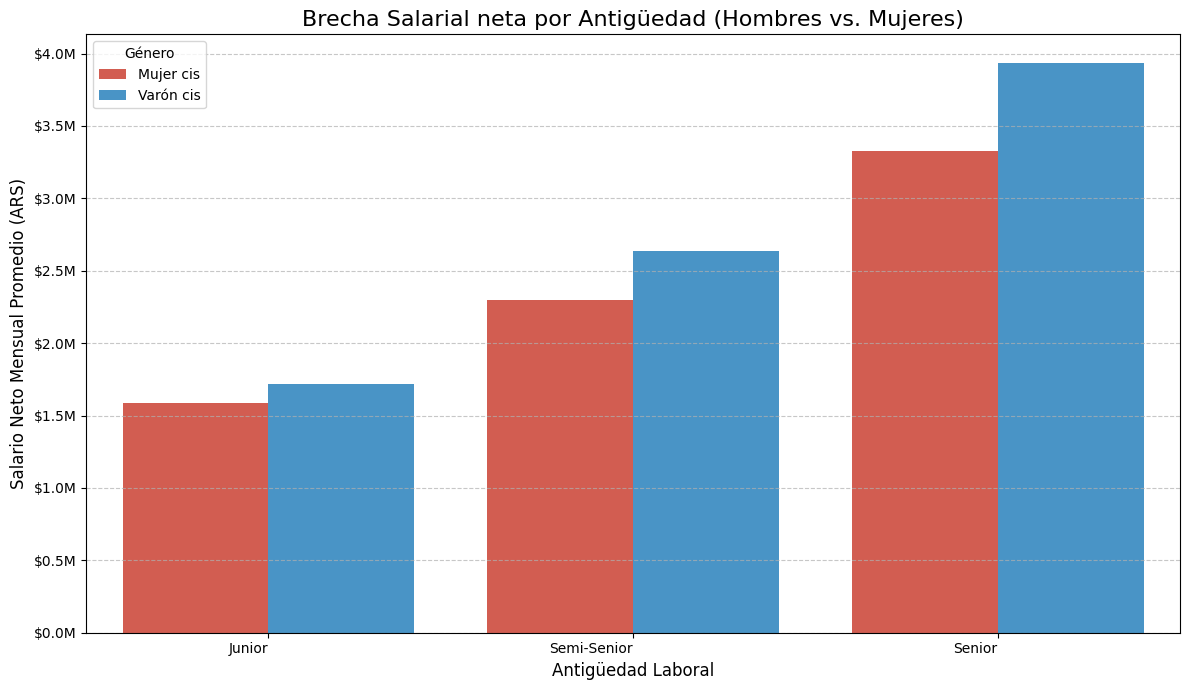

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Filtrar el DataFrame usando los mismos criterios que groupA y groupB.
df_filtered = df[(15000000 > df.salary_monthly_NETO) & (df.salary_monthly_NETO > 100000) & (df.profile_g.isin(['Varón cis', 'Mujer cis']))].copy()

# Definir el orden deseado para los niveles de antigüedad, centrándose en los datos disponibles.
seniority_order = [
    'Junior',
    'Semi-Senior',
    'Senior'
]

# Convertir 'work_seniority' en un tipo categórico con el orden especificado.
df_filtered['work_seniority'] = pd.Categorical(df_filtered['work_seniority'], categories=seniority_order, ordered=True)

# Agrupar por antigüedad y género, y luego calcular el salario neto medio.
salary_by_seniority_gender = df_filtered.groupby(['work_seniority', 'profile_g'], observed=False)['salary_monthly_NETO'].mean().reset_index()

# Filtrar cualquier nivel de antigüedad que pueda no existir después de aplicar la orden.
salary_by_seniority_gender = salary_by_seniority_gender.dropna(subset=['work_seniority'])

# Crear el gráfico de barras agrupadas con colores.
plt.figure(figsize=(12, 7))
ax = sns.barplot(
x='work_seniority',
y='salary_monthly_NETO',
hue='profile_g',
data=salary_by_seniority_gender,
palette={'Varón cis': '#3498db', 'Mujer cis': '#e74c3c'} # Using more vibrant blue and red
)

# Formatear el eje Y en millones de pesos
formatter = mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M')
ax.yaxis.set_major_formatter(formatter)

plt.title('Brecha Salarial neta por Antigüedad (Hombres vs. Mujeres)', fontsize=16)
plt.xlabel('Antigüedad Laboral', fontsize=12)
plt.ylabel('Salario Neto Mensual Promedio (ARS)', fontsize=12)
plt.xticks(rotation=0, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Género')
plt.tight_layout()
plt.show()

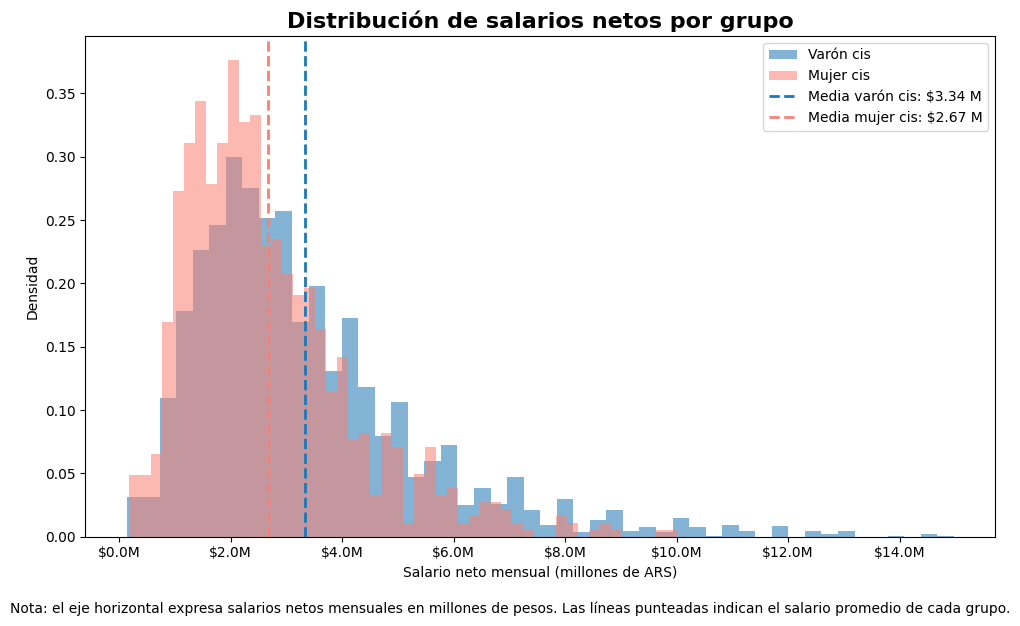

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # Importar mticker

# Pasamos salarios a millones de pesos
salary_A_millions = groupA / 1_000_000
salary_B_millions = groupB / 1_000_000

meanA_millions = salary_A_millions.mean()
meanB_millions = salary_B_millions.mean()

plt.figure(figsize=(10, 6))

plt.hist(
    salary_A_millions,
    bins=50,
    alpha=0.55,
    density=True,
    label="Varón cis"
)

plt.hist(
    salary_B_millions,
    bins=50,
    alpha=0.55,
    density=True,
    label="Mujer cis",
    color='salmon'
)

# Líneas de medias
plt.axvline(
    meanA_millions,
    linestyle="--",
    linewidth=2,
    label=f"Media varón cis: ${meanA_millions:.2f} M"
)

plt.axvline(
    meanB_millions,
    linestyle="--",
    linewidth=2,
    label=f"Media mujer cis: ${meanB_millions:.2f} M",
    color='salmon'
)

plt.title("Distribución de salarios netos por grupo", fontsize=16, weight="bold")
plt.xlabel("Salario neto mensual (millones de ARS)")
plt.ylabel("Densidad")
plt.legend()

# Obtener el objeto de ejes actual para aplicar el formateador
ax = plt.gca()

# Formatear el eje X en millones de pesos
formatter = mticker.FuncFormatter(lambda x, p: f'${x:.1f}M')
ax.xaxis.set_major_formatter(formatter)

plt.figtext(
    0.5, -0.03,
    "Nota: el eje horizontal expresa salarios netos mensuales en millones de pesos. "
    "Las líneas punteadas indican el salario promedio de cada grupo.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

---

### Propuesta de Post para LinkedIn/Tweet

**La Brecha Salarial de Género persiste en la industria Tech** 📊

Nuestro análisis de la encuesta Sysarmy 2026 revela una diferencia significativa en el salario neto mensual promedio entre hombres y mujeres. El gráfico muestra cómo esta brecha se manifiesta en distintos niveles de antigüedad laboral.

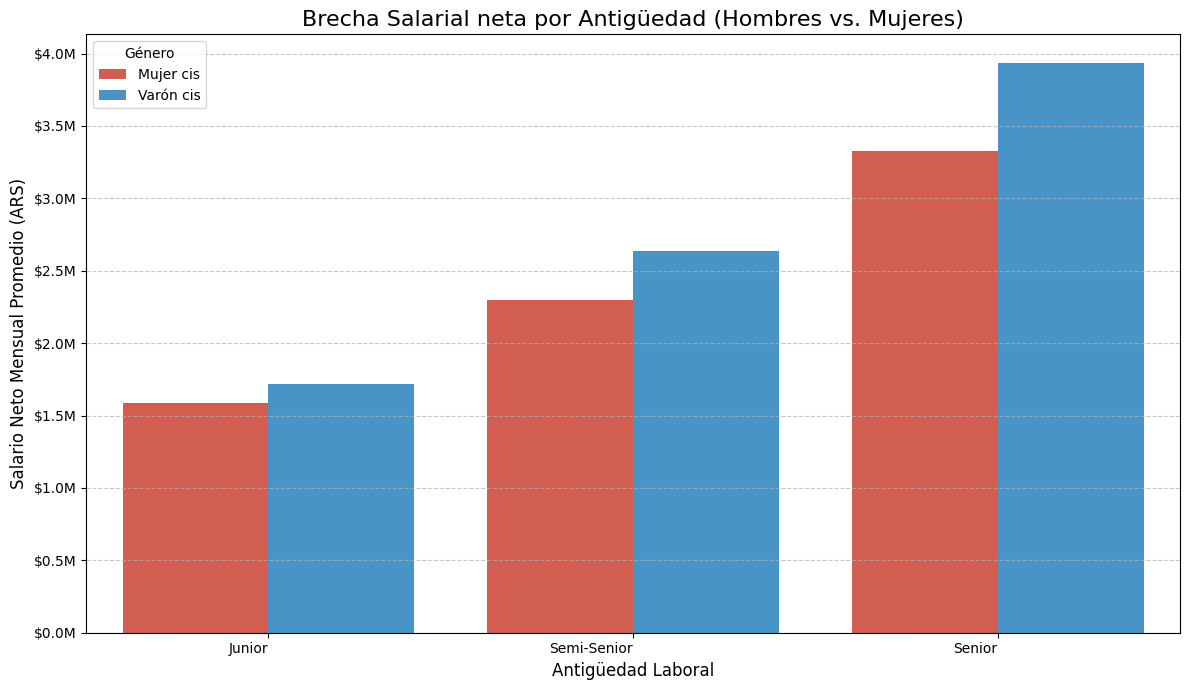

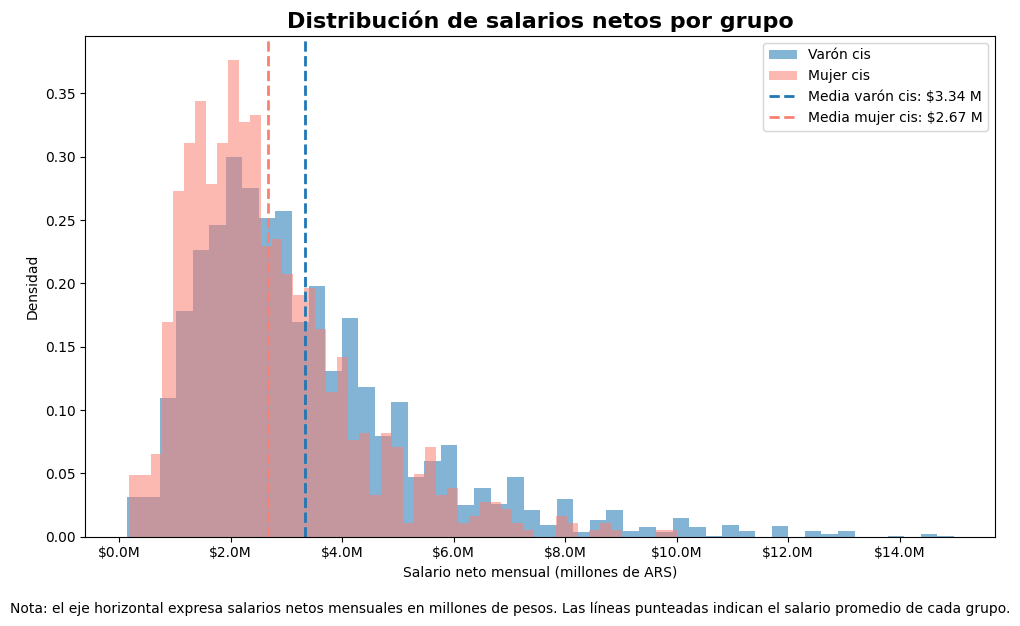

**Observaciones Clave:**
* La diferencia salarial es evidente en todas las categorías de antigüedad.
* A medida que aumenta la antigüedad, la brecha en valores absolutos tiende a ampliarse.

Este hallazgo subraya la importancia de promover la equidad salarial y políticas de inclusión en el ámbito laboral.

**#BrechaSalarial #EquidadDeGénero #DataScience #SalariosArgentina**

---

**Sobre los Datos:**
Este análisis se realizó utilizando datos de la encuesta Sysarmy 2026, una encuesta abierta que recopila información sobre salarios y condiciones laborales en Argentina. Para este estudio, se filtraron los salarios netos mensuales entre ARS 100.000 y ARS 15.000.000, considerando las respuestas de hombres cisgénero y mujeres cisgénero.